In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


X_train = pd.read_csv('X_train.csv', index_col=0, sep=',')
X_train.columns.name = 'date'

Y_train = pd.read_csv('Y_train.csv', index_col=0, sep=',')
Y_train.columns.name = 'date'

In [2]:
x_np1 = X_train.to_numpy().T
x_np = np.stack([np.flip(x_np1[i:i+250], axis=0).T for i in range(len(x_np1)-250)])
y_np = Y_train.to_numpy().T

x_torch = torch.tensor(x_np)
y_torch = torch.tensor(y_np)



#statistical data per stock item; to do robust scaling

Mean = np.mean(x_np1, axis=0)
#print("Mean:", np.mean(x_np1, axis=0))
#print(" ")

Median = np.median(x_np1, axis=0)
print("Median:", np.median(x_np1, axis=0))
print(" ")

Median_to_size_xnp1 = np.array([Median]*754)
Median_to_size_ynp = np.array([Median]*504)

Q1 = np.quantile(x_np1, 0.25, axis=0)
#print("Q1:", np.quantile(x_np1, 0.25, axis=0))
#print(" ")

Q3 = np.quantile(x_np1, 0.75, axis=0)
#print("Q3:", np.quantile(x_np1, 0.75, axis=0))
#print(" ")


IQR = Q3-Q1
IQR_to_size_xnp1 = np.array([IQR]*754)
IQR_to_size_ynp = np.array([IQR]*504)


#print("IQR_to_size_xnp1: ", IQR_to_size_xnp1.shape)
#print("IQR_to_size_ynp:", IQR_to_size_ynp.shape)
#print(" ")

print("IQR:", IQR)
print(" ")

x_robust_rescaled=(x_np1 - Median_to_size_xnp1)/(IQR_to_size_xnp1)
y_robust_rescaled=(y_np - Median_to_size_ynp)/(IQR_to_size_ynp)

print("Rescaled x_np1:",x_robust_rescaled)
print(" ")

X_robust_rescaled = torch.tensor(x_robust_rescaled, dtype=torch.float32).T
x_np_robust = np.stack([np.flip(x_robust_rescaled[i:i+250], axis=0).T for i in range(len(x_np1)-250)])

x_robust_torch = torch.tensor(x_np_robust)
y_robust_torch = torch.tensor(y_robust_rescaled)

df = pd.DataFrame(X_robust_rescaled) #convert to a dataframe
df.to_csv("X_robust_rescaled_file.csv",index=False) #save to file

# To keep track of dimensions of torches
# print(x_torch.shape)
# print(y_torch.shape)
# print(X_robust_rescaled.shape)
# print(x_robust_torch.shape)
# print(y_robust_torch.shape)


Median: [-1.96882118e-04  2.12487513e-04 -1.67393890e-04  4.57901495e-04
  5.20588506e-04 -1.68296517e-05 -5.07232573e-04  5.73184649e-05
 -5.79522971e-04  2.52878017e-04 -5.82327214e-05 -9.84641842e-04
  1.23278509e-03 -4.65206927e-04 -5.84864847e-06 -1.82868517e-03
  3.70681046e-05 -9.93748647e-04 -5.00167311e-04  1.15043449e-03
  3.44569880e-04  1.95256637e-04 -4.54343476e-04  1.13250876e-04
 -1.94343118e-05 -5.35199730e-04 -1.69804542e-04  4.28697649e-04
 -7.52472848e-05  9.84019751e-04  4.98128878e-05  2.63846292e-04
 -1.14050250e-03 -7.46645522e-04  7.53453142e-04  1.81464268e-05
  6.00007031e-04  6.68362311e-05  1.66344899e-04  2.64783355e-04
  7.81944504e-04 -3.05121810e-04  4.77869132e-04 -1.49761799e-03
 -4.22592018e-04 -9.28513055e-04 -2.02847518e-04  8.85728961e-04
 -1.72861877e-04 -7.90272433e-05]
 
IQR: [0.01429006 0.00836004 0.01115812 0.01320995 0.01222006 0.01294483
 0.01793974 0.00884633 0.01103704 0.01199766 0.00900135 0.0198199
 0.01390748 0.01222978 0.01175143 0.01

In [3]:
#def detect_outliers_iqr(data):
#    Q1 = np.percentile(data, 25, axis=1)
#    Q3 = np.percentile(data, 75, axis=1)    
#    IQR = Q3 - Q1
    
#    lower_bound = Q1 - 1.5 * IQR
#    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers: values outside the bounds
#    outliers = (data < lower_bound[:, None]) | (data > upper_bound[:, None])
    
#    return outliers

# Detect outliers for each stock
#outliers_iqr = detect_outliers_iqr(x_np1)
#print("Outliers based on IQR:\n", outliers_iqr)




def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25, axis=0)
    Q3 = np.percentile(data, 75, axis=0)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers: values outside the bounds
    outliers = (data < lower_bound) | (data > upper_bound)
    
    return outliers, lower_bound, upper_bound

outliers_iqr, lower_bound, upper_bound = detect_outliers_iqr(x_np1)

# Print outliers detected based on IQR for the stocks with more than 25 outliers
print("Outliers based on IQR:")
for i in range(outliers_iqr.shape[1]):
    outlier_indices = np.where(outliers_iqr[:, i])[0]
    if len(outlier_indices) > 25:
        print(f"\nStock {i+1}:",)
        print(len(outlier_indices), f"Outliers detected on days: {outlier_indices + 1}")  # Adding 1 to make it 1-indexed (days)
        print(f"Lower Bound: {lower_bound[i]}, Upper Bound: {upper_bound[i]}")
#    else:
#        print("No outliers detected.")
        
# A bit too many outliers for precise predictions...       
print("")
print("")
print("")
print("")
print("")



# Print outliers detected based on IQR for the stocks with more than 36 outliers (5% of 754 days)
print("5% Outliers based on IQR:")
for i in range(outliers_iqr.shape[1]):
    outlier_indices = np.where(outliers_iqr[:, i])[0]
    if len(outlier_indices) > 36:
        print(f"\nStock {i+1}:",)
        print(len(outlier_indices), f"Outliers detected on days: {outlier_indices + 1}")  # Adding 1 to make it 1-indexed (days)
        print(f"Lower Bound: {lower_bound[i]}, Upper Bound: {upper_bound[i]}")
#    else:
#        print("No outliers detected.")
        
# A bit too many outliers for precise predictions...    


Outliers based on IQR:

Stock 5:
28 Outliers detected on days: [  1  16  30  70  71  87 116 123 153 166 204 212 216 236 241 372 398 399
 404 405 406 466 506 621 655 705 714 718]
Lower Bound: -0.024103119027497212, Upper Bound: 0.024777123929920687

Stock 7:
32 Outliers detected on days: [  4  21  32  94 115 163 220 256 288 326 329 404 414 416 444 453 467 468
 474 516 521 539 544 593 610 626 643 646 662 666 737 742]
Lower Bound: -0.03618513844470432, Upper Bound: 0.03557380877282827

Stock 9:
37 Outliers detected on days: [ 10  14  46  50  70 113 136 139 158 174 181 185 189 197 207 218 262 264
 328 384 403 405 411 426 427 429 440 442 446 450 515 548 567 641 646 693
 714]
Lower Bound: -0.022463838321850265, Upper Bound: 0.02168433586378124

Stock 15:
44 Outliers detected on days: [  5  12  13  18  28  70 115 117 132 197 213 257 268 275 313 328 403 414
 432 434 435 436 437 440 442 457 505 506 519 520 528 535 554 555 563 569
 579 616 624 674 686 705 710 725]
Lower Bound: -0.023471582369635

In [4]:
# To undo robust scaling to compute the metric during optimization using Lion, Adam, or AdamW
Median_to_size_ynp_rescale = torch.tensor(np.array([Median]*504)) # of torch size [504,50]
IQR_to_size_ynp_rescale = torch.tensor(np.array([IQR]*504)) # of torch size [504,50]

1.0251536384043474
-1.1885559063775035


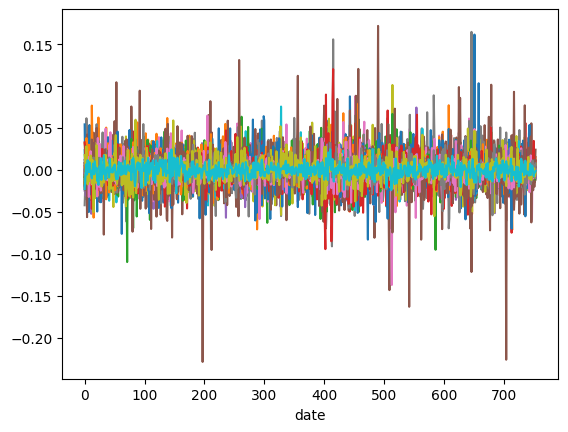

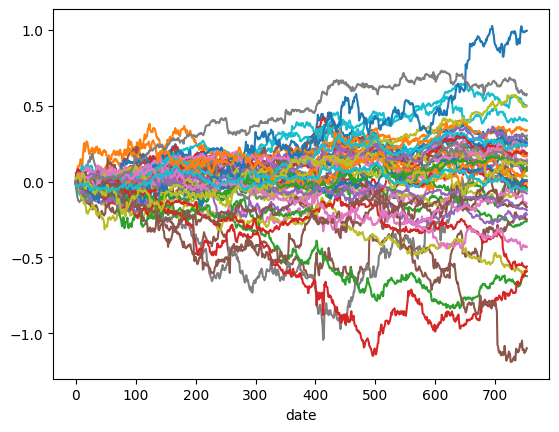

(50, 754)
66.765797596
-52.74489968799999


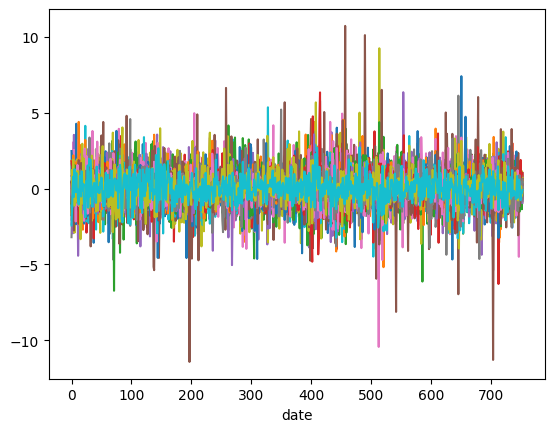

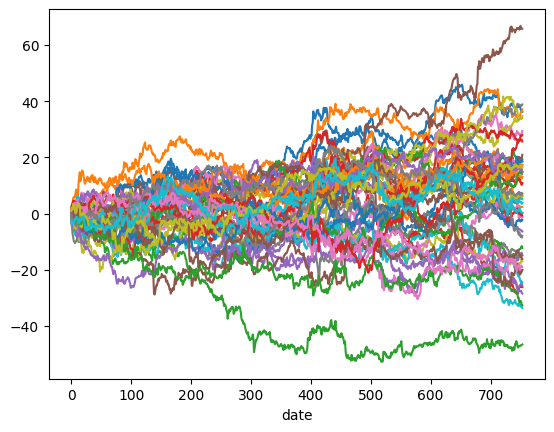

torch.Size([504, 50, 250])


In [5]:
X_train.T.plot(legend=False)
X_train.T.cumsum().plot(legend=False)
Sum_of_X = X_train.T.cumsum()
print(np.max(Sum_of_X))
print(np.min(Sum_of_X))
plt.show()
print(X_train.shape)


x_robust_rescaled = pd.read_csv('X_robust_rescaled_file2.csv', index_col=0, sep=',')   
# 'X_robust_rescaled_file2.csv' was quickly altered using excel by simply adding index of stockID from 'X_robust_rescaled_file.csv' which was previously created above.
x_robust_rescaled.columns.name = 'date'
x_robust_rescaled.T.plot(legend=False)
x_robust_rescaled.T.cumsum().plot(legend=False)
Sum_of_robust_rescaled_X = x_robust_rescaled.T.cumsum()
print(np.max(Sum_of_robust_rescaled_X))
print(np.min(Sum_of_robust_rescaled_X))
plt.show()
x_robust_rescaled=x_robust_rescaled.to_numpy().T
#x_np = np.stack([np.flip(x_np1[i:i+250], axis=0).T for i in range(len(x_np1)-250)])
x_robust_rescaled = np.stack([np.flip(x_robust_rescaled[i:i+250], axis=0).T for i in range(len(x_robust_rescaled)-250)])
x_robust_rescaled=torch.tensor(x_robust_rescaled)
print(x_robust_rescaled.shape)


In [6]:
df = pd.read_csv("X_train.csv")

# Define outlier metadata
outliers_info = {
       5: {"days": [1, 16, 30, 70, 71, 87, 116, 123, 153, 166, 204, 212, 216, 236, 241, 372, 398, 399,
                 404, 405, 406, 466, 506, 621, 655, 705, 714, 718],
        "lower": -0.024103119027497212, "upper": 0.024777123929920687},
    
    7: {"days": [4, 21, 32, 94, 115, 163, 220, 256, 288, 326, 329, 404, 414, 416, 444, 453, 467, 468,
                 474, 516, 521, 539, 544, 593, 610, 626, 643, 646, 662, 666, 737, 742],
        "lower": -0.03618513844470432, "upper": 0.03557380877282827},
    
    9: {"days": [10, 14, 46, 50, 70, 113, 136, 139, 158, 174, 181, 185, 189, 197, 207, 218, 262, 264,
                 328, 384, 403, 405, 411, 426, 427, 429, 440, 442, 446, 450, 515, 548, 567, 641, 646, 693, 714],
        "lower": -0.022463838321850265, "upper": 0.02168433586378124},
    
    15: {"days": [5, 12, 13, 18, 28, 70, 115, 117, 132, 197, 213, 257, 268, 275, 313, 328, 403, 414,
                  432, 434, 435, 436, 437, 440, 442, 457, 505, 506, 519, 520, 528, 535, 554, 555, 563,
                  569, 579, 616, 624, 674, 686, 705, 710, 725],
        "lower": -0.02347158236963586, "upper": 0.023534136021766836},
    
    16: {"days": [51, 71, 128, 147, 181, 211, 213, 239, 240, 254, 338, 400, 401, 403, 404, 406, 408, 415,
                  423, 426, 432, 448, 460, 461, 473, 491, 598, 627, 647, 677, 680, 682, 683, 691],
         "lower": -0.03501802024710479, "upper": 0.03368301090956291},
    
    20: {"days": [4, 11, 13, 29, 30, 34, 42, 53, 54, 70, 78, 147, 192, 202, 207, 220, 270, 329,
                  362, 405, 440, 442, 443, 453, 454, 516, 527, 565, 629, 630, 631, 646, 650],
         "lower": -0.027324253137288337, "upper": 0.028399366674799562},

    22: {"days": [2, 3, 4, 7, 16, 20, 46, 53, 63, 77, 80, 83, 162, 303, 330, 392, 399, 404,
                  405, 406, 433, 435, 454, 456, 457, 487, 522, 579, 648, 706, 713, 714, 737],
         "lower": -0.016562206301857715, "upper": 0.016734357301321987},
    
    27: {"days": [5, 9, 18, 25, 36, 78, 125, 139, 206, 245, 270, 287, 292, 307, 338, 370, 372, 401,
                  402, 403, 433, 476, 497, 514, 516, 520, 571, 580, 624, 670, 677, 748],
         "lower": -0.026640531628230088, "upper": 0.025754843956850012},

    28: {"days": [1, 3, 24, 31, 43, 50, 52, 55, 64, 65, 67, 69, 71, 77, 99, 128, 213, 236,
                  237, 243, 291, 358, 362, 400, 405, 443, 460, 527, 667],
         "lower": -0.026379116781821612, "upper": 0.026424880741743886},
    
    29: {"days": [9, 10, 14, 18, 35, 49, 55, 117, 132, 171, 178, 183, 262, 293, 298, 319, 328, 329,
                  348, 381, 397, 403, 426, 434, 446, 505, 522, 538, 585, 598, 633, 641, 685, 708, 736],
         "lower": -0.030326107626572764, "upper": 0.029880353742786935},

    33: {"days": [72, 74, 79, 82, 88, 99, 106, 110, 134, 135, 139, 144, 165, 170, 201, 225, 343, 363,
                  403, 405, 413, 414, 446, 452, 459, 460, 488, 505, 515, 545, 553, 595, 675, 718],
         "lower": -0.0330433060787263, "upper": 0.0313587351790513},
    
    36: {"days": [2, 15, 73, 75, 138, 139, 173, 175, 202, 204, 257, 268, 312, 328, 329, 390, 398, 403,
                  405, 430, 433, 442, 444, 458, 470, 478, 486, 519, 577, 628, 637, 642, 643, 705],
         "lower": -0.02260375138046461, "upper": 0.022403983658985688},

    37: {"days": [13, 71, 102, 117, 143, 232, 272, 357, 403, 404, 406, 407, 415, 437, 438, 442, 452, 464,
                  468, 482, 485, 517, 520, 521, 522, 540, 585, 586, 630, 655, 660, 730],
         "lower": -0.02154057808556519, "upper": 0.021716869639186915},

    39: {"days": [6, 19, 25, 35, 111, 203, 221, 222, 231, 232, 265, 312, 365, 372, 409, 418, 446, 457,
                  461, 463, 467, 482, 483, 517, 597, 610, 631, 647, 660, 722, 740],
         "lower": -0.021176908985305484, "upper": 0.021905937409700812},

    41: {"days": [1, 8, 22, 56, 63, 109, 125, 146, 203, 225, 244, 282, 286, 289, 294, 300, 301, 331,
                  357, 373, 403, 415, 444, 457, 458, 474, 487, 507, 529, 609, 629, 652, 659, 714, 737, 744],
         "lower": -0.042066867192326676, "upper": 0.04478496269548092},

    43: {"days": [108, 109, 121, 146, 266, 273, 283, 287, 288, 290, 338, 372, 396, 402, 404, 405, 414, 440,
                  445, 457, 460, 492, 524, 550, 552, 576],
         "lower": -0.017355804666027524, "upper": 0.017378085858073673},

    44: {"days": [13, 135, 198, 199, 237, 253, 402, 403, 404, 405, 408, 413, 414, 415, 416, 422, 442, 445,
                  450, 453, 460, 462, 466, 507, 510, 554, 556, 580, 601, 612, 641, 677, 679, 718, 737],
         "lower": -0.03951931886553085, "upper": 0.037409208395542556},

    46: {"days": [5, 33, 81, 93, 94, 112, 121, 135, 136, 140, 147, 149, 156, 180, 198, 213, 258, 259,
                  286, 312, 356, 357, 378, 384, 435, 444, 454, 508, 515, 543, 563, 612, 626, 636, 676,
                  678, 695, 705, 717, 718, 727, 736, 746, 747],
         "lower": -0.0405635387330331, "upper": 0.03915232224748551},

    49: {"days": [16, 52, 53, 70, 75, 82, 85, 86, 125, 149, 192, 211, 256, 338, 362, 398, 403, 453,
                  464, 510, 521, 526, 527, 565, 629, 646, 652],
         "lower": -0.029937122245072785, "upper": 0.02984855657857591}

}

# Apply clipping for each specified stock
for stock_id, info in outliers_info.items():
    for day in info["days"]:
        day_col = str(day)  # column names are strings
        original_value = df.loc[df["stocksID"] == stock_id, day_col].values[0]
        clipped_value = min(max(original_value, info["lower"]), info["upper"])
        df.loc[df["stocksID"] == stock_id, day_col] = clipped_value

# Save the cleaned dataset
df.to_csv("X_train_cleaned_for_optimizer.csv", index=False)

In [7]:
X_train_cleaned = pd.read_csv('X_train_cleaned_for_optimizer.csv', index_col=0, sep=',')
X_train.columns.name = 'date'

x_np1_cleaned = X_train_cleaned.to_numpy().T
x_np_cleaned = np.stack([np.flip(x_np1_cleaned[i:i+250], axis=0).T for i in range(len(x_np1_cleaned)-250)])
y_np_same = Y_train.to_numpy().T

x_torch_cleaned = torch.tensor(x_np_cleaned)
y_torch_same = torch.tensor(y_np_same)





#statistical data per stock item; to do robust scaling

Mean_cleaned = np.mean(x_np1_cleaned, axis=0)
#print("Mean:", np.mean(x_np1, axis=0))
#print(" ")

Median_cleaned = np.median(x_np1_cleaned, axis=0)
print("Median:", np.median(x_np1_cleaned, axis=0))
print(" ")

Median_to_size_xnp1_cleaned = np.array([Median_cleaned]*754)
Median_to_size_ynp_same = np.array([Median_cleaned]*504)

Q1_cleaned = np.quantile(x_np1_cleaned, 0.25, axis=0)
#print("Q1:", np.quantile(x_np1, 0.25, axis=0))
#print(" ")

Q3_cleaned = np.quantile(x_np1_cleaned, 0.75, axis=0)
#print("Q3:", np.quantile(x_np1, 0.75, axis=0))
#print(" ")


IQR_cleaned = Q3_cleaned - Q1_cleaned
IQR_to_size_xnp1_cleaned = np.array([IQR_cleaned]*754)
IQR_to_size_ynp_same = np.array([IQR_cleaned]*504)



x_robust_rescaled_cleaned=(x_np1_cleaned - Median_to_size_xnp1_cleaned)/(IQR_to_size_xnp1_cleaned)
y_robust_rescaled_same=(y_np_same - Median_to_size_ynp_same)/(IQR_to_size_ynp_same)

print("Rescaled x_np1:",x_robust_rescaled_cleaned)
print(" ")

X_robust_rescaled_cleaned = torch.tensor(x_robust_rescaled_cleaned, dtype=torch.float32).T
x_np_robust_cleaned = np.stack([np.flip(x_robust_rescaled_cleaned[i:i+250], axis=0).T for i in range(len(x_np1_cleaned)-250)])

x_robust_torch_cleaned = torch.tensor(x_np_robust_cleaned)
y_robust_torch_same = torch.tensor(y_robust_rescaled_same)

df = pd.DataFrame(X_robust_rescaled_cleaned) #convert to a dataframe
#df.to_csv("X_robust_rescaled_file.csv",index=False) #save to file
# To keep track of dimensions of torches
print(x_torch_cleaned.shape)
print(y_torch_same.shape)
print(X_robust_rescaled_cleaned.shape)
print(x_robust_torch_cleaned.shape)
print(y_robust_torch_same.shape)

Median: [-1.96882118e-04  2.12487513e-04 -1.67393890e-04  4.57901495e-04
  5.20588506e-04 -1.68296517e-05 -5.07232573e-04  5.73184649e-05
 -5.79522971e-04  2.52878017e-04 -5.82327214e-05 -9.84641842e-04
  1.23278509e-03 -4.65206927e-04 -5.84864847e-06 -1.82868517e-03
  3.70681046e-05 -9.93748647e-04 -5.00167311e-04  1.15043449e-03
  3.44569880e-04  1.95256637e-04 -4.54343476e-04  1.13250876e-04
 -1.94343118e-05 -5.35199730e-04 -1.69804542e-04  4.28697649e-04
 -7.52472848e-05  9.84019751e-04  4.98128878e-05  2.63846292e-04
 -1.14050250e-03 -7.46645522e-04  7.53453142e-04  1.81464268e-05
  6.00007031e-04  6.68362311e-05  1.66344899e-04  2.64783355e-04
  7.81944504e-04 -3.05121810e-04  4.77869132e-04 -1.49761799e-03
 -4.22592018e-04 -9.28513055e-04 -2.02847518e-04  8.85728961e-04
 -1.72861877e-04 -7.90272433e-05]
 
Rescaled x_np1: [[-1.29112952 -1.01276429 -0.73816111 ... -0.59996811  1.21014039
  -2.42911569]
 [-0.89606333 -2.69051055 -1.2064446  ... -1.03723418  0.79092779
  -1.32473216

In [8]:
Median_to_size_ynp_rescale_cleaned = torch.tensor(np.array([Median_cleaned]*504)) # of torch size [504,50]
IQR_to_size_ynp_rescale_cleaned = torch.tensor(np.array([IQR_cleaned]*504)) # of torch size [504,50]

In [9]:
import torch
from torch import nn, Tensor

class NNmodel(nn.Module):
    def __init__(self, D=250, F=10) -> None:
        super().__init__()
        self.D = D
        self.F = F     
        
        # Define the weights for the skew-symmetric matrix, with size D*(D-1)/2
        self.weight = nn.Parameter(torch.randn((D*(D-1)//2), dtype=torch.float64))
        # Define the beta parameters for the linear combination in the forward pass
        self.beta_parameters = nn.Parameter(torch.randn((F), dtype=torch.float64))

    @property
    def generator(self) -> Tensor:

# Generate the skew-symmetric matrix based on the weights. The upper triangular part of the matrix is filled with weights and the matrix is made Skew-symmetric from preSkew_symmetric.

        preSkew_symmetric = torch.zeros((self.D, self.D), dtype=torch.float64)
        
        # Fill the upper triangular part with the weights
        upper_triangle_indices = torch.triu_indices(self.D, self.D, offset=1)
        preSkew_symmetric[upper_triangle_indices[0], upper_triangle_indices[1]] = self.weight
        
        # Make the matrix skew-symmetric
        Skew_symmetric = preSkew_symmetric - preSkew_symmetric.T
        return Skew_symmetric
    
    @property     
    def A(self) -> Tensor:
        # Return the exponential of the generator fitted to the size (D, F).
        return torch.matrix_exp(self.generator)[:,:self.F]
    def learning_factors(self, x: Tensor) -> Tensor:
        # In this case, we will assume the factors are a simple linear transformation.
        return torch.matmul(x, self.A)  # (batch_size, D) x (D, F) -> (batch_size, F)
    
# output through forward-pairing required to run the nn.module neural network
    def forward(self, x: Tensor) -> Tensor:
        # The linear combination of the factors with the beta parameters.
        return torch.matmul(self.learning_factors(x), self.beta_parameters)  # (batch_size, F) x (F) -> (batch_size)



In [10]:
def metric_comparison(y1: Tensor, y2: Tensor) -> Tensor:
    # Normalize both tensors
    y1 = y1.div(y1.norm(keepdim=True, dim=1))
    y2 = y2.div(y2.norm(keepdim=True, dim=1))
    
    # Compute cosine similarity using the sum of element-wise products
    cosine_similarities = torch.sum(y1 * y2, dim=1)  # Element-wise product and sum along feature dimension
    return cosine_similarities.mean()

In [11]:
import torch

import time
start_time = time.time()

# Ensure random seed is set (assuming torch.seed is supposed to be set via torch.manual_seed)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

# Initialize tracking variables for the best model and metrics
maxMetric = {'model1': -1}
updated_model = {'model1': None}
Metric_storage = {'model1': {'metric': []}}

n = 1000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

# Using AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

model.train()

for t in range(n):
    optimizer.zero_grad()

    # Calculate the evaluation metric
    eval = metric_comparison(model(x_torch), y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()

    # Convert evaluation value to a scalar and append it to the storage
    eval_value = eval.item()
    Metric_storage['model1']['metric'].append(eval_value)

    # Update the model if the evaluation is better than the current best metric
    if eval_value > maxMetric['model1']:
        maxMetric['model1'] = eval_value
        updated_model['model1'] = model
        updated_model['model1'].train(False)  # Switch to evaluation mode

    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")



print("--- %s seconds ---" % (time.time() - start_time))




After   0 iterations, we have improved the metric to 0.0100266
After 300 iterations, we have improved the metric to 0.1490932
After 600 iterations, we have improved the metric to 0.1490932
After 900 iterations, we have improved the metric to 0.1490932
--- 25.4026837348938 seconds ---


In [12]:
A_flat1 = updated_model['model1'].A.reshape(2500)

print(A_flat1.shape) 

output1=torch.cat((A_flat1, updated_model['model1'].beta_parameters), dim=0)
print(output1.shape)
print(output1)
output1=torch.tensor(output1)
output_Kim1 = pd.DataFrame(output1)#convert to a dataframe

# To generate the final output of size [2510] from model 1
output_Kim1.to_csv("Output_Kim1.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0861,  0.0022,  0.0036,  ...,  0.0483, -0.4127,  1.6737],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_26016/1414586899.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output1=torch.tensor(output1)


In [13]:
import torch

# Ensure random seed is set (assuming `torch.seed` is supposed to be set via `torch.manual_seed`)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

n = 3000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Initialize storage for metrics
maxMetric = {'model2': -1}
updated_model = {'model2': None}
Metric_storage = {'model2': {'metric': []}}

model.train()

for t in range(n):
    optimizer.zero_grad()
    
    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_torch)) * IQR_to_size_ynp_rescale) + Median_to_size_ynp_rescale
    
    # Compute metric and loss
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()
    
    # Convert the evaluation to a scalar
    eval_value = eval.item()
    Metric_storage['model2']['metric'].append(eval_value)
    
    # Update the model if we find an improvement
    if eval_value > maxMetric['model2']:
        maxMetric['model2'] = eval_value
        updated_model['model2'] = model
        updated_model['model2'].train(False)  # Switch to evaluation mode
    
    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")


After   0 iterations, we have improved the metric to 0.0129496
After 300 iterations, we have improved the metric to 0.1476569
After 600 iterations, we have improved the metric to 0.1476852
After 900 iterations, we have improved the metric to 0.1477343
After 1200 iterations, we have improved the metric to 0.1478262
After 1500 iterations, we have improved the metric to 0.1480527
After 1800 iterations, we have improved the metric to 0.1496103
After 2100 iterations, we have improved the metric to 0.1502693
After 2400 iterations, we have improved the metric to 0.1502693
After 2700 iterations, we have improved the metric to 0.1502691


In [14]:
A_flat2 = updated_model['model2'].A.reshape(2500)

print(A_flat2.shape) 

output2=torch.cat((A_flat2, updated_model['model2'].beta_parameters), dim=0)
print(output2.shape)
print(output2)
output2=torch.tensor(output2)
output_Kim2 = pd.DataFrame(output2)#convert to a dataframe

# To generate the final output of size [2510] from model 2
output_Kim2.to_csv("Output_Kim2.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0863,  0.0133,  0.0730,  ..., -0.0002, -0.0091,  0.1578],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_26016/193509323.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output2=torch.tensor(output2)


In [15]:
import torch

# Ensure random seed is set (assuming torch.seed is supposed to be set via torch.manual_seed)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

# Initialize tracking variables for the best model and metrics
maxMetric = {'model3': -1}
updated_model = {'model3': None}
Metric_storage = {'model3': {'metric': []}}

n = 3000
output_dim = 1
model = NNmodel()


# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

# Using AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Set the model to training mode
model.train()

for t in range(n):
    optimizer.zero_grad()

    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_rescaled)) * IQR_to_size_ynp_rescale) + Median_to_size_ynp_rescale
    
    # Calculate the evaluation metric
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()

    # Convert evaluation value to a scalar and append it to the storage
    eval_value = eval.item()
    Metric_storage['model3']['metric'].append(eval_value)

    # Update the model if the evaluation is better than the current best metric
    if eval_value > maxMetric['model3']:
        maxMetric['model3'] = eval_value
        updated_model['model3'] = model
        updated_model['model3'].train(False)  # Switch to evaluation mode

    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.7f}")


After   0 iterations, we have improved the metric to 0.0129497
After 300 iterations, we have improved the metric to 0.1476569
After 600 iterations, we have improved the metric to 0.1476852
After 900 iterations, we have improved the metric to 0.1477343
After 1200 iterations, we have improved the metric to 0.1478262
After 1500 iterations, we have improved the metric to 0.1480527
After 1800 iterations, we have improved the metric to 0.1496103
After 2100 iterations, we have improved the metric to 0.1502693
After 2400 iterations, we have improved the metric to 0.1502693
After 2700 iterations, we have improved the metric to 0.1502693


In [16]:
A_flat3 = updated_model['model3'].A.reshape(2500)

print(A_flat3.shape) 

output3=torch.cat((A_flat3, updated_model['model3'].beta_parameters), dim=0)
print(output3.shape)
print(output3)
output3=torch.tensor(output3)
output_Kim3 = pd.DataFrame(output3)#convert to a dataframe

# To generate the final output of size [2510] from model 3
output_Kim3.to_csv("Output_Kim3.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0863,  0.0133,  0.0730,  ..., -0.0002, -0.0091,  0.1578],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_26016/2557498632.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output3=torch.tensor(output3)


In [17]:
print(updated_model['model3'].A)

tensor([[ 0.0863,  0.0133,  0.0730,  ...,  0.0375, -0.1141, -0.0249],
        [-0.0694,  0.0492, -0.0421,  ..., -0.0068,  0.0092,  0.0193],
        [ 0.0487,  0.0550, -0.0876,  ...,  0.0503, -0.0668, -0.0843],
        ...,
        [ 0.1392,  0.0723, -0.0674,  ..., -0.1020,  0.1198,  0.1169],
        [ 0.0076, -0.0702, -0.0711,  ..., -0.0333,  0.0721,  0.0324],
        [ 0.0544, -0.0502,  0.0091,  ...,  0.1095,  0.0490, -0.1682]],
       dtype=torch.float64, grad_fn=<SliceBackward0>)


In [18]:
print(updated_model['model3'].A.shape)

torch.Size([250, 10])


In [19]:
print(updated_model['model3'].beta_parameters)

Parameter containing:
tensor([-0.0052, -0.0073,  0.0064,  0.0229,  0.1772,  0.0084,  0.0026, -0.0002,
        -0.0091,  0.1578], dtype=torch.float64, requires_grad=True)


In [20]:
print(updated_model['model3'].beta_parameters.shape)

torch.Size([10])


In [21]:
#Somehow the data removing outliers outside of IQR does not help improving the learning process.
#Robust scaling with outliers gives better predictions.

import torch

# Ensure random seed is set (assuming `torch.seed` is supposed to be set via `torch.manual_seed`)
torch.manual_seed(42)  # Set the random seed for reproducibility (or change the seed as needed)

n = 5000
output_dim = 1
model = NNmodel()

# from lion_pytorch import Lion
#optimizer = Lion(model.parameters(), lr=1e-4, weight_decay=1e-2)

#optimizer = torch.optim.Adam(model.parameters())

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-2)

# Initialize storage for metrics
maxMetric = {'model4': -1}
updated_model = {'model4': None}
Metric_storage = {'model4': {'metric': []}}

model.train()

for t in range(n):
    optimizer.zero_grad()
    
    # Undo robust scaling using in-place operations to minimize memory usage
    updated_x = ((model(x_robust_torch_cleaned)) * IQR_to_size_ynp_rescale_cleaned) + Median_to_size_ynp_rescale_cleaned
    # Compute metric and loss
    eval = metric_comparison(updated_x, y_torch)
    loss = -eval
    loss.backward()
    optimizer.step()
    
    # Convert the evaluation to a scalar
    eval_value = eval.item()
    Metric_storage['model4']['metric'].append(eval_value)
    
    # Update the model if we find an improvement
    if eval_value > maxMetric['model4']:
        maxMetric['model4'] = eval_value
        updated_model['model4'] = model
        updated_model['model4'].train(False)  # Switch to evaluation mode
    
    # Print progress every 300 iterations
    if t % 300 == 0:
        print(f"After {t:3d} iterations, we have improved the metric to {eval_value:1.5f}")

After   0 iterations, we have improved the metric to 0.01231
After 300 iterations, we have improved the metric to 0.14754
After 600 iterations, we have improved the metric to 0.14757
After 900 iterations, we have improved the metric to 0.14761
After 1200 iterations, we have improved the metric to 0.14770
After 1500 iterations, we have improved the metric to 0.14793
After 1800 iterations, we have improved the metric to 0.14949
After 2100 iterations, we have improved the metric to 0.15017
After 2400 iterations, we have improved the metric to 0.15017
After 2700 iterations, we have improved the metric to 0.15017
After 3000 iterations, we have improved the metric to 0.15017
After 3300 iterations, we have improved the metric to 0.15017
After 3600 iterations, we have improved the metric to 0.15017
After 3900 iterations, we have improved the metric to 0.15017
After 4200 iterations, we have improved the metric to 0.15017
After 4500 iterations, we have improved the metric to 0.15017
After 4800 i

In [22]:
A4_flat = updated_model['model4'].A.reshape(2500)

print(A4_flat.shape) 

output4=torch.cat((A4_flat, updated_model['model4'].beta_parameters), dim=0)
print(output4.shape)
print(output4)
output4=torch.tensor(output4)
output_Kim4 = pd.DataFrame(output4)#convert to a dataframe

# To generate the final output of size [2510] from model 4
output_Kim4.to_csv("Output_Kim4.csv",index=True) #save to file

torch.Size([2500])
torch.Size([2510])
tensor([ 0.0933,  0.0224,  0.1311,  ..., -0.0026, -0.0094,  0.1461],
       dtype=torch.float64, grad_fn=<CatBackward0>)


/var/folders/tt/944h4xl91ll9w1sjmrxxzcmr0000gq/T/ipykernel_26016/2016537951.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output4=torch.tensor(output4)
